In [5]:
import matplotlib.pyplot as plt
import matplotlib
# font options
font = {
#     'family' : 'normal',
    #'weight' : 'bold',
    'size'   : 22
}
matplotlib.rc('font', **{'family': 'serif', })
plt.rc('font', **font)
plt.rc('lines', linewidth=3, markersize=10)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [90]:
# expe2_results= {
#     "MFLD contour": {
#         "X_fin": None
#     },
#     "MFLD": {
#         "X_fin": None,
#         "KGD_values": None,
#         "gradL_eval": None
#     },

#     "Variational Inference": {
#         "X_fin": None,
#         "KGD_values": None,
#         "gradL_eval": None},

#     "KGD Descent": {
#         "X_fin": None,
#         "KGD_values": None,
#         "gradL_eval": None
#     }
# }

In [1]:
kernel_name = "recommended_kernel"
filename = f"saved_data/expe2_results_{kernel_name}.pkl"

In [2]:
# import pickle

# # Sauvegarde dans un fichier binaire
# with open(filename, "wb") as gg:
#     pickle.dump(expe2_results, gg)

In [3]:
import jax.numpy as jnp
import pickle

# Chargement depuis le fichier
with open(filename, "rb") as g:
    expe2_results_loaded = pickle.load(g)

In [6]:
def kde_mfld(x):
    X = expe2_results_loaded["MFLD contour"]["X_fin"][:,:2]
    n = X.shape[0]
    h = 15.0 / jnp.sqrt(n)

    diff = (X - x) / h
    sq_dist = jnp.sum(diff**2, axis=1)

    norm_const = 1.0 / (n * (2 * jnp.pi)**(X.shape[1] / 2) * h**X.shape[1])

    density = norm_const * jnp.sum(jnp.exp(-0.5 * sq_dist))
    return density

kernel used for KGD evaluation: recommended_kernel


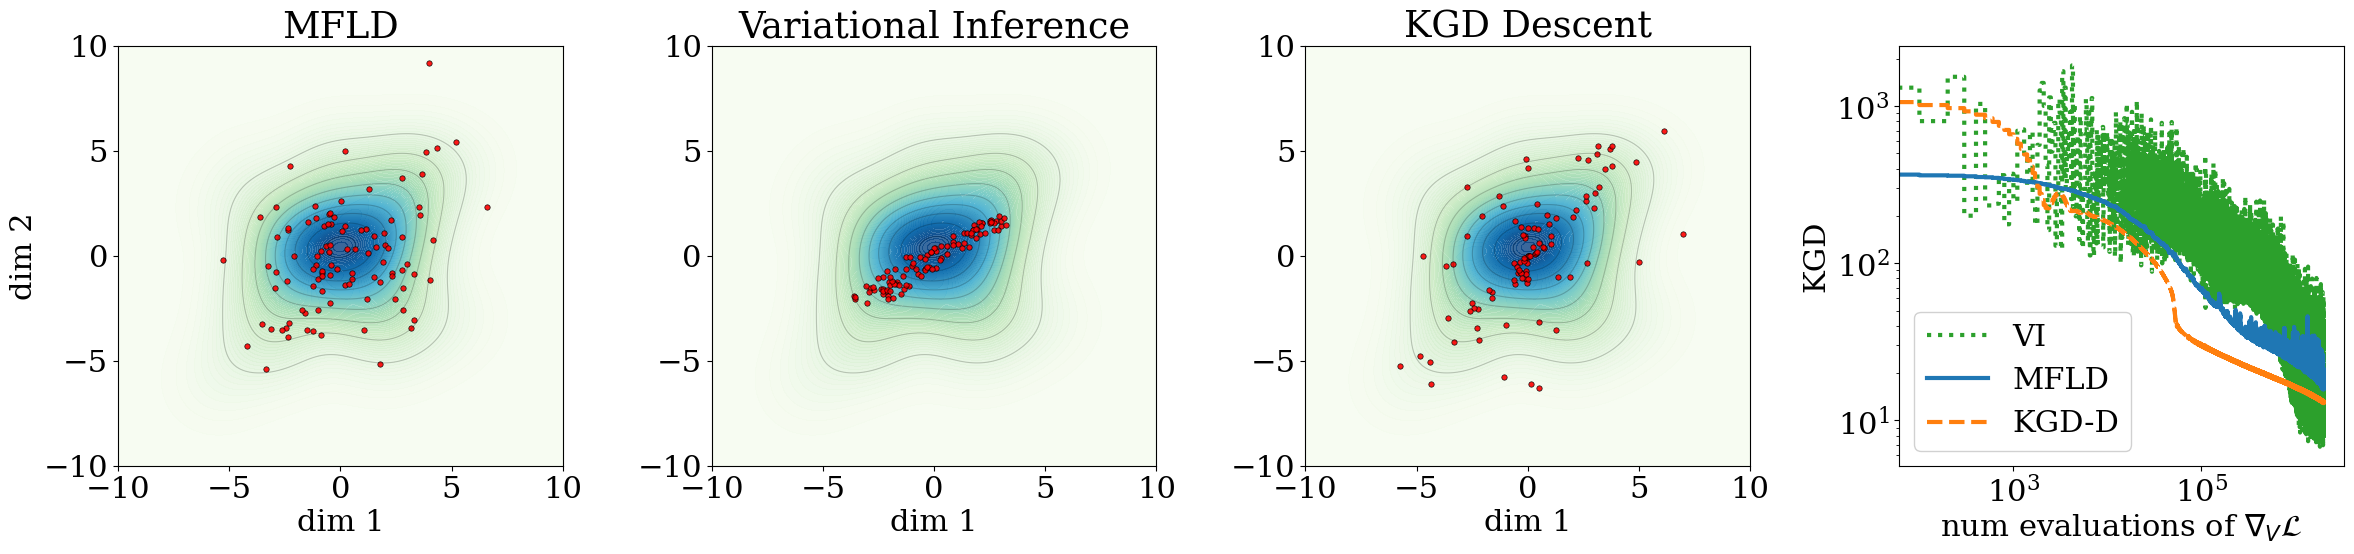

In [ ]:
mean = jnp.zeros(2)  
cov = jnp.eye(2) * 2.0  

x = jnp.linspace(-10, 10, 200)
y = jnp.linspace(-10, 10, 200)
X, Y = jnp.meshgrid(x, y)
Z = jnp.array([[kde_mfld(jnp.array([x, y])) for x in x] for y in y])
    

fig, axes = plt.subplots(1, 4, figsize=(16*1.5, 4*1.5))

for ind, expe in enumerate(list(expe2_results_loaded.keys())[1:-1]):
    
    
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          
        cmap='GnBu', 
        alpha=0.8    
    )
    
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.2
    )
    
   
    axes[ind].scatter(
        expe2_results_loaded[expe]["X_fin"][:, 0],
        expe2_results_loaded[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    axes[ind].set_xlabel('dim 1')
    axes[ind].set_ylabel('dim 2')
    axes[ind].set_title(expe)
    #axes[ind].legend()
axes[1].set_ylabel("")
axes[2].set_ylabel("")

axes[3].step(expe2_results_loaded["Variational Inference"]["gradL_eval"],
    expe2_results_loaded["Variational Inference"]["KGD_values"], 
    label="VI", 
    linestyle=':',
    color = "tab:green"
)
axes[3].step(expe2_results_loaded["MFLD"]["gradL_eval"],
    expe2_results_loaded["MFLD"]["KGD_values"], 
    label="MFLD", 
    linestyle='-',
    color = "tab:blue"
)
axes[3].step(expe2_results_loaded["KGD Descent"]["gradL_eval"],
    expe2_results_loaded["KGD Descent"]["KGD_values"], 
    label="KGD-D", 
    linestyle='--',
    color = "tab:orange"
)

axes[3].legend()
axes[3].set_xscale("log")
axes[3].set_yscale("log")
axes[3].set_xlabel(r"num evaluations of $\nabla_V \mathcal{L}$")
axes[3].set_ylabel("KGD")
#plt.title("KGD")
plt.tight_layout()
axes[3].legend(
    loc='best',
    framealpha=0.9,
    facecolor='white'
)

print("kernel used for KGD evaluation: " + kernel_name)